In [18]:
import pandas as pd

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt



In [19]:
df = pd.read_csv('train.csv')

In [20]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
250,251,0,3,"Reed, Mr. James George",male,NaN,0,0,362316,7.25,NaN,S
607,608,1,1,"Daniel, Mr. Robert Williams",male,27.0,0,0,113804,30.50,NaN,S
848,849,0,2,"Harper, Rev. John",male,28.0,0,1,248727,33.00,NaN,S
754,755,1,2,"Herman, Mrs. Samuel (Jane Laver)",female,48.0,1,2,220845,65.00,NaN,S
648,649,0,3,"Willey, Mr. Edward",male,NaN,0,0,S.O./P.P. 751,7.55,NaN,S


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [22]:
df.describe(
    
)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:
# Idade e um daado valioso e que representava um numero grande de missing values, foram substituidos pela media de idade 

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked']= df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(columns= 'Cabin')

In [25]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

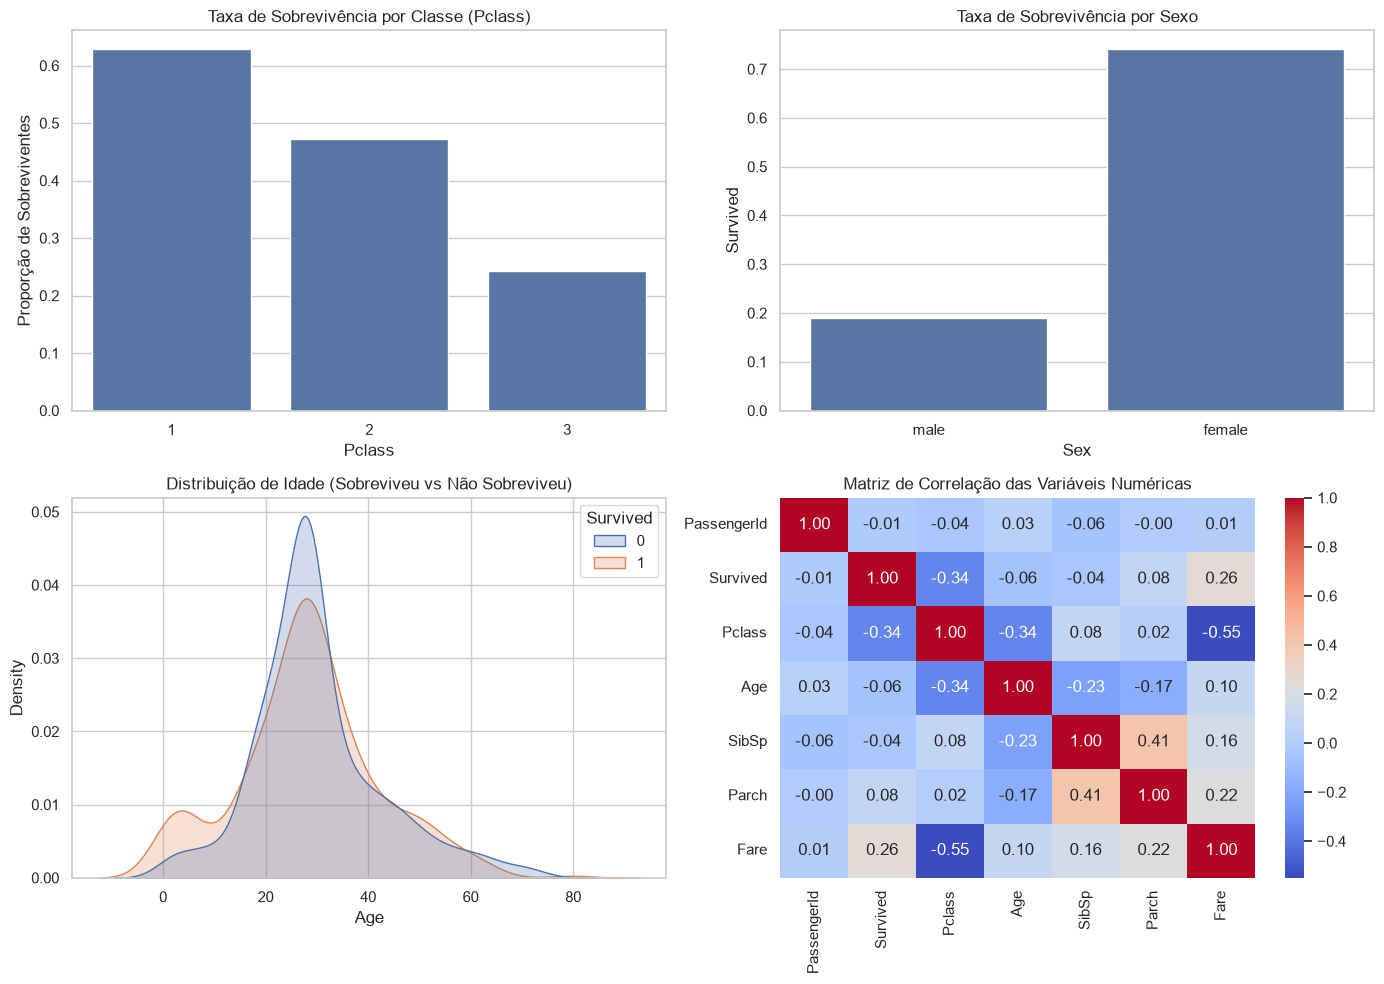

In [26]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(14,10))
# Grafico sobrevivencia por classe 1 top 2 mais ou menos 3 mais pra menos
# subplot determina onde a figura vai ficar 2 linha 2 coluna e 1 quadrante
plt.subplot(2,2,1)

sns.barplot(x='Pclass', y='Survived', data=df, errorbar=None)

plt.title('Taxa de Sobrevivência por Classe (Pclass)')
plt.ylabel('Proporção de Sobreviventes')
# subplot determina onde a figura vai ficar 2 linha 2 coluna e 2 quadrante
plt.subplot(2,2,2)
sns.barplot(x='Sex', y='Survived', data=df, errorbar=None)
plt.title('Taxa de Sobrevivência por Sexo')
# Gráfico 3: Distribuição de Idades por Sobrevivência

plt.subplot(2, 2, 3)

sns.kdeplot(data=df, x='Age', hue='Survived', common_norm=False, fill=True)

plt.title('Distribuição de Idade (Sobreviveu vs Não Sobreviveu)')
# Gráfico 4: Matriz de Correlação

plt.subplot(2, 2, 4)

numeric_df = df.select_dtypes(include=[np.number])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Matriz de Correlação das Variáveis Numéricas')

plt.tight_layout()



In [27]:
from sklearn.model_selection import train_test_split
# family size e uma colunaa que representa quantos membros a familia tem utilizando a coluna parentes e pais 
df['familySize']= df['SibSp'] + df['Parch'] +1
df['isAlone']= (df['familySize']==1).astype(int)
df.columns

features = ['Age','Embarked','Pclass','Sex','familySize','isAlone', 'Fare']

X= df[features]
y= df['Survived']

X= pd.get_dummies(X,columns=['Sex','Embarked'] , drop_first=True)

X_train, X_test , y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y )

print(f"Dimensão do treino: {X_train.shape}")
print(f"Dimensão do teste: {X_test.shape}")


Dimensão do treino: (712, 8)
Dimensão do teste: (179, 8)


In [28]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Instanciar

modelo_dt = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')

# 2. Treinar

modelo_dt.fit(X_train, y_train)

# 3. Predizer

y_pred_dt = modelo_dt.predict(X_test)
# 4. Avaliar

acuracia_dt = accuracy_score(y_test, y_pred_dt)

print(f"--- Árvore de Decisão ---")

print(f"Acurácia: {acuracia_dt * 100:.2f}%\n")

print("Relatório de Classificação:")

print(classification_report(y_test, y_pred_dt))

print( confusion_matrix(y_test, y_pred_dt))

--- Árvore de Decisão ---
Acurácia: 75.98%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       110
           1       0.65      0.81      0.72        69

    accuracy                           0.76       179
   macro avg       0.76      0.77      0.76       179
weighted avg       0.78      0.76      0.76       179

[[80 30]
 [13 56]]


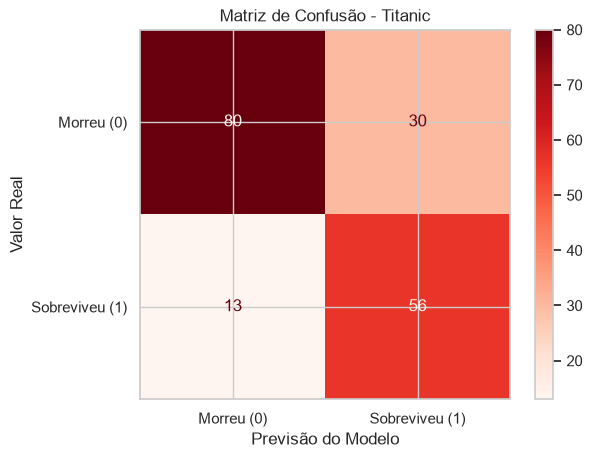

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
matriz =confusion_matrix(y_test, y_pred_dt)
# Exibe o gráfico diretamente a partir da sua matriz
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, 
                              display_labels=['Morreu (0)', 'Sobreviveu (1)'])

# Altera a cor para tons de azul (opcional)
disp.plot(cmap=plt.cm.Reds)

plt.title('Matriz de Confusão - Titanic')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.show()

In [30]:

# Importando novos modelos do Scikit-Learn

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC
resultados = {}
modelos = {

"Regressão Logística": LogisticRegression(max_iter=1000, random_state=42),

"Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),

"KNN (k-Nearest Neighbors)": KNeighborsClassifier(n_neighbors=5),

"SVM (Support Vector Machine)": SVC(random_state=42)

}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred= modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados[nome] = acc
    print(f"Acurácia do {nome}: {acc * 100:.2f}%")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))

Acurácia do Regressão Logística: 79.33%
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.70      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

[[94 16]
 [21 48]]
Acurácia do Random Forest: 81.56%
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179

[[96 14]
 [19 50]]
Acurácia do KNN (k-Nearest Neighbors): 66.48%
              precision    recall  f1-score   support

           0       0.71      0.77      0.74       110
           1       0.58      0.49      0.53        69

    accuracy            

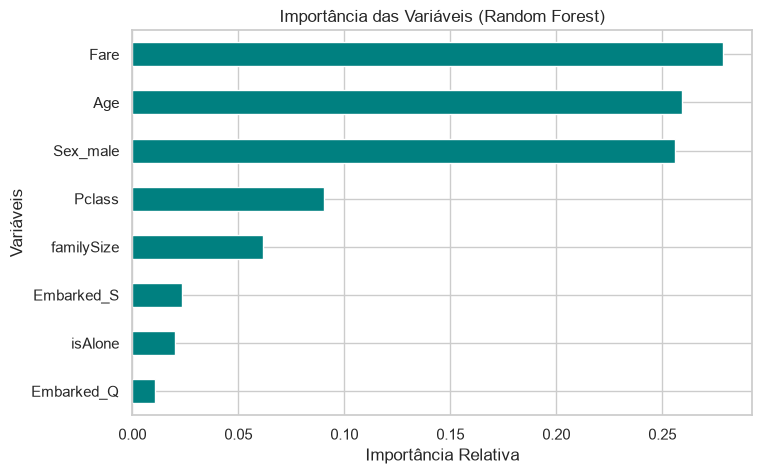

In [31]:
modelo_rf= RandomForestClassifier()
modelo_rf.fit(X_train, y_train)

# Extraindo a importância relativa dos recursos
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train.columns)

importancias = importancias.sort_values(ascending=True)


plt.figure(figsize=(8, 5))

importancias.plot(kind='barh', color='teal')

plt.title('Importância das Variáveis (Random Forest)')

plt.xlabel('Importância Relativa')

plt.ylabel('Variáveis')

plt.show()